# Hotel Booking Demand

## Business Objective

The objective of this project is to analyze hotel booking behavior and identify the factors associated with booking cancellations, customer demand, and hotel performance.

The findings can help hotel managers improve occupancy rates, reduce cancellations, and optimize business decisions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import statsmodels.api as sm
import scipy.stats as stats

# Load the Dataset

In [2]:
df=pd.read_csv('hotel_bookings.csv')

# Data Understanding

In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.shape

(119390, 32)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


#  Data Cleaning Process

In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
df["children"] = df["children"].fillna(0)

df["country"] = df["country"].fillna("Unknown")

df["agent"] = df["agent"].fillna(0)

df["company"] = df["company"].fillna(0)

In [9]:
df.isnull().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
company                           0
days_in_waiting_list              0
customer_type                     0
adr                         

In [10]:
df.duplicated().sum()

np.int64(31994)

In [11]:
df=df.drop_duplicates()

In [12]:
df.shape

(87396, 32)

## Data CLeaning
1. Checked for missing values
2. Filled missing values in agent, children, country and company
3. Removed duplicate records

# Business Questions

## What percentage of hotel bookings are canceled?

In [13]:
df['is_canceled'].value_counts()

is_canceled
0    63371
1    24025
Name: count, dtype: int64

In [14]:
df['is_canceled'].value_counts(normalize=True)*100

is_canceled
0    72.510184
1    27.489816
Name: proportion, dtype: float64

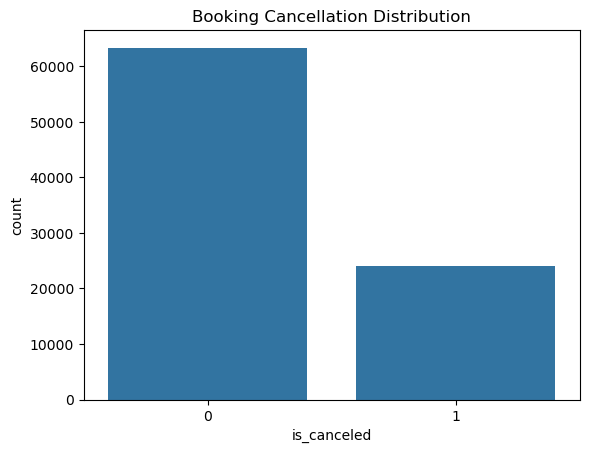

In [15]:
plt.figure()
sns.countplot(x=df['is_canceled'])
plt.title('Booking Cancellation Distribution')
plt.show()
              

**Most of the customers do not cancel(62.95%) but there is a decent amount of customers that cancel(37.04%)**

## Which hotel type experiences more cancellations?

In [16]:
hotel_cancel = pd.crosstab(df['hotel'],df['is_canceled'],normalize='index')*100
hotel_cancel

is_canceled,0,1
hotel,,
City Hotel,69.961443,30.038557
Resort Hotel,76.519077,23.480923


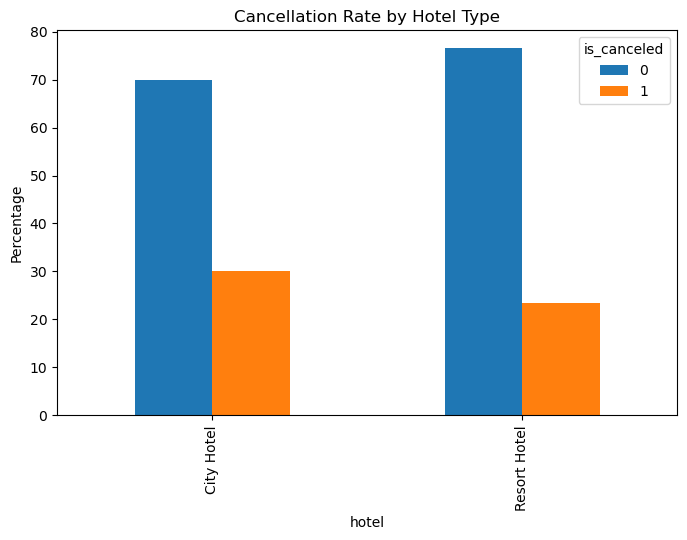

In [17]:
hotel_cancel.plot(kind='bar',figsize=(8,5))
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('Percentage')
plt.show()

**Most of the cancellations happen in City Hotel (41.72%) while in Resort Hotel the cancellations are much lower(27.76%,aproximately 1/4 people cancel)** 

## Does lead time affect booking cancellations?

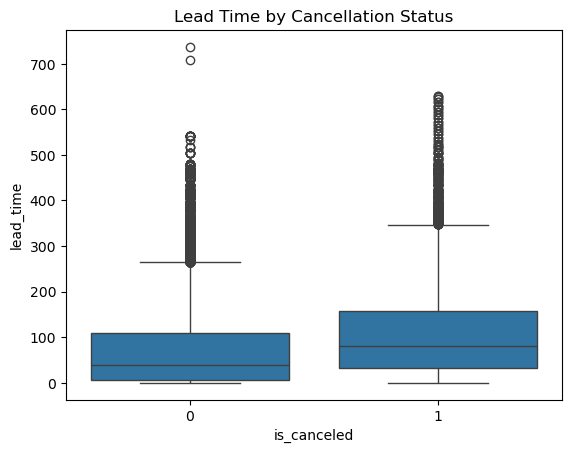

In [18]:
plt.figure()
sns.boxplot( x=df['is_canceled'],y=df['lead_time'])
plt.title('Lead Time by Cancellation Status')
plt.show()

**People who did not cancel booked on average only ~50 days in advance. People who cancelled booked ~110 days in advance — more than double. This is a very strong and clear signal.**

**This happens why if you book a hotel tomorrow or next week you are almost certainly going — you have a concrete plan. If you book 6 months in advance you are less certain — plans change, you find a better deal, life happens.**

## Which customer types cancel most frequently?

In [19]:
customer_cancel = pd.crosstab( df['customer_type'],df['is_canceled'],normalize='index')*100
customer_cancel

is_canceled,0,1
customer_type,,
Contract,83.689073,16.310927
Group,90.073529,9.926471
Transient,69.894146,30.105854
Transient-Party,84.761661,15.238339


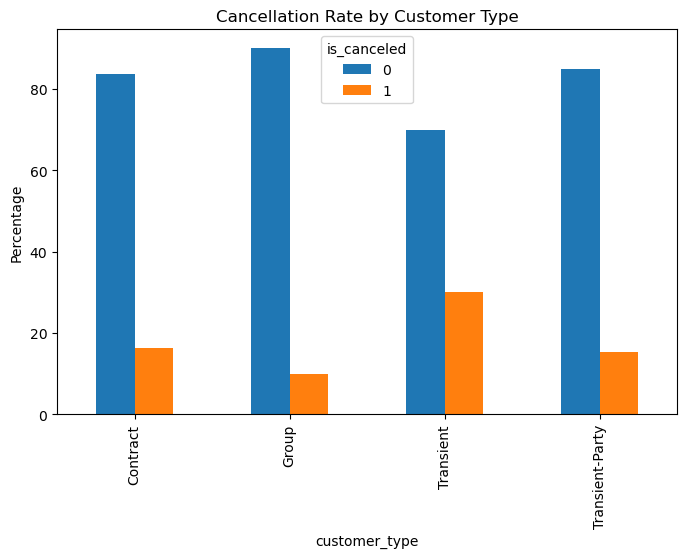

In [20]:
customer_cancel.plot(kind='bar',figsize=(8,5))
plt.title('Cancellation Rate by Customer Type')
plt.ylabel('Percentage')
plt.show()

**Transient — 40.75% → nearly 1 in 2 cancels — worst
Contract — 30.96% → about 1 in 3 cancels
Transient-Party — 25.43% → 1 in 4 cancels
Group — 10.23% → almost nobody cancels — best**

**Transient customers are individual walk-in or last-minute bookers — no commitment, easy to cancel**

**Group bookings are organized trips (tours, conferences, weddings) — very hard to cancel because many people are involved**

**Contract customers have a business agreement with the hotel — some flexibility but still committed**

**Transient-Party is a small group of transient customers traveling together — slightly more committed than solo transient**

## Which countries generate the most bookings?

In [21]:
top_countries = df['country'].value_counts().head(10)
top_countries

country
PRT    27453
GBR    10433
FRA     8837
ESP     7252
DEU     5387
ITA     3066
IRL     3016
BEL     2081
BRA     1995
NLD     1911
Name: count, dtype: int64

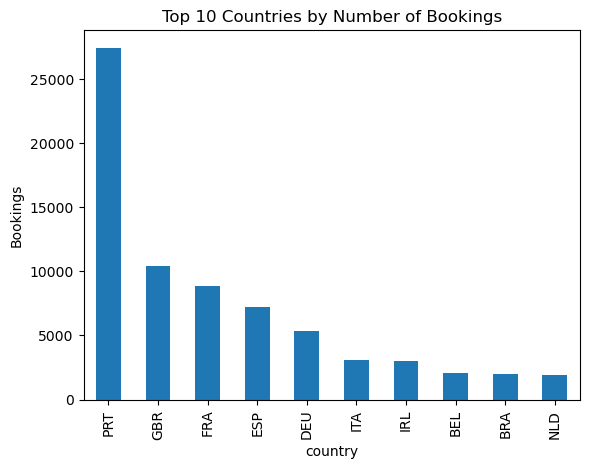

In [22]:
plt.figure()
top_countries.plot(kind='bar')
plt.title('Top 10 Countries by Number of Bookings')
plt.ylabel('Bookings')
plt.show()

**Portugal has nearly 4x more bookings than the UK (second place) and almost 5x more than France (third). This is an enormous gap.**

**This makes complete sense when you think about it — the dataset is from a Portuguese hotel company. So most of their customers are naturally local (Portuguese) guests or tourists already visiting Portugal. The other countries are international tourists traveling to Portugal.**

## Which months have the highest booking demand?

In [23]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
monthly_bookings = df['arrival_date_month'].value_counts().reindex(month_order)

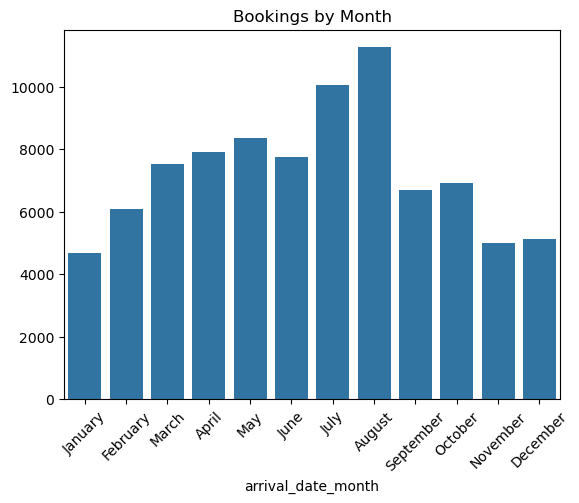

In [24]:
plt.figure()
sns.barplot(x=monthly_bookings.index,y=monthly_bookings.values)
plt.title('Bookings by Month')
plt.xticks(rotation=45)
plt.show()

**1 — Summer is peak season (July–August)
August is the busiest month with ~11,000 bookings — more than double January. This is classic tourist behavior in a European hotel.**

**2 — Clear low season in winter (November–February)
Bookings drop significantly in the winter months, with January being the quietest at ~4,500.**

**3 — Spring builds steadily
Bookings grow consistently from February through July — people planning their summer holidays.**

**4 — Sharp drop after August
September and October drop quickly as summer ends, then stabilize through winter.**

## Does Average Daily Rate (ADR) influence cancellations?

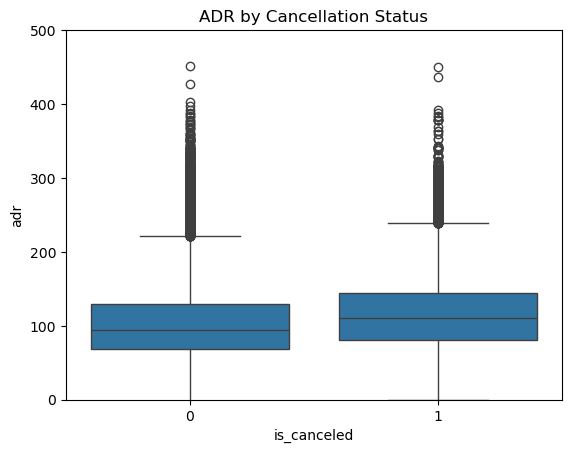

In [25]:
sns.boxplot(x=df['is_canceled'], y=df['adr'])
plt.ylim(0, 500)  # focus on the range where data actually lives
plt.title('ADR by Cancellation Status')
plt.show()

**The main finding — ADR has very little effect on cancellations:
The two boxes are almost identical in position and size. The median difference is only ~10 (100 vs 110) — extremely small. This tells you that the daily rate alone does not strongly predict whether someone cancels or not.**

## Which market segments generate the most bookings?


In [26]:
market_segment_counts = df['market_segment'].value_counts()
market_segment_counts

market_segment
Online TA        51618
Offline TA/TO    13889
Direct           11804
Groups            4942
Corporate         4212
Complementary      702
Aviation           227
Undefined            2
Name: count, dtype: int64

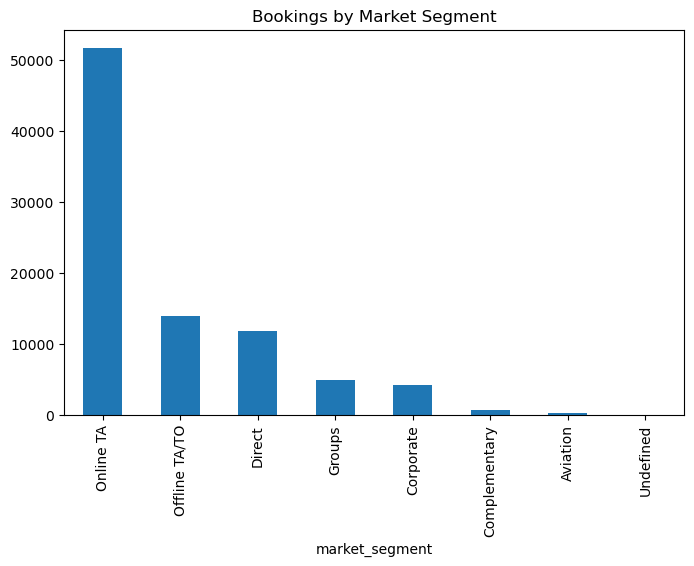

In [27]:
plt.figure(figsize=(8,5))
market_segment_counts.plot(kind='bar')
plt.title('Bookings by Market Segment')
plt.show()

**Different market segments contribute differently to hotel demand**

**Online TA has  approximately 52,000 bookings — nearly 4x more than Offline TA (second place) and more than all other segments combined. This is a massive dominance.**


## Which distribution channels are most effective?

In [28]:
distribution_counts = df['distribution_channel'].value_counts()
distribution_counts

distribution_channel
TA/TO        69141
Direct       12988
Corporate     5081
GDS            181
Undefined        5
Name: count, dtype: int64

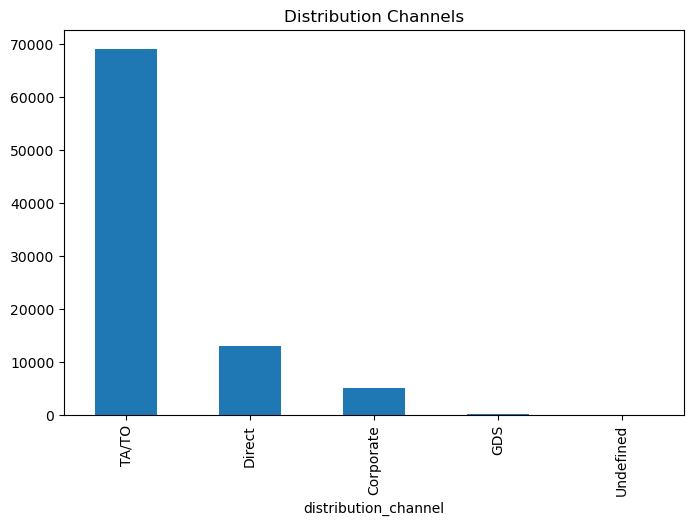

In [29]:
plt.figure(figsize=(8,5))
distribution_counts.plot(kind='bar')
plt.title('Distribution Channels')
plt.show()

**TA/TO has ~70,000 bookings — 5x more than Direct and 14x more than Corporate. Even more extreme than the market segment chart.**

## Does the number of special requests affect cancellations?

In [30]:
special_request_cancel = pd.crosstab(df['total_of_special_requests'],df['is_canceled'],normalize='index')*100
special_request_cancel

is_canceled,0,1
total_of_special_requests,,
0,66.797284,33.202716
1,77.589000,22.411000
2,78.708093,21.291907
3,82.865775,17.134225
4,89.375000,10.625000
5,94.444444,5.555556


<Figure size 800x500 with 0 Axes>

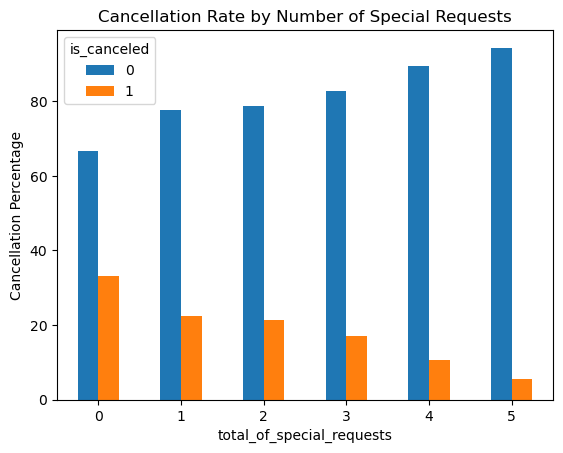

In [31]:
plt.figure(figsize=(8,5))
special_request_cancel.plot(kind='bar')
plt.title('Cancellation Rate by Number of Special Requests')
plt.ylabel('Cancellation Percentage')
plt.xticks(rotation=0)
plt.show()

**This is a perfectly consistent downward trend in cancellations as special requests increase. From 34% cancellation with 0 requests all the way down to just 6% with 5 requests.**

# Executive Summary

This project analyzed hotel booking demand data from a Portuguese hotel company comprising **87,396 bookings** across two hotel types — City Hotel and Resort Hotel — after data cleaning. The analysis focused on identifying the key drivers of booking cancellations, understanding customer behavior, and uncovering seasonal and geographic booking patterns.

The overall cancellation rate stands at **37%**, which is a significant business problem. Through exploratory data analysis, eight key factors were examined: hotel type, lead time, customer type, country of origin, seasonality, average daily rate, market segment, distribution channel, and number of special requests. The analysis reveals that cancellations are not random — they follow clear, predictable patterns that the hotel can act upon.

**Key numbers at a glance:**
- Total bookings analyzed: 87,396
- Overall cancellation rate: 37.04%
- City Hotel cancellation rate: 41.72%
- Resort Hotel cancellation rate: 27.76%
- Peak booking month: August (~11,000 bookings)
- Dominant market: Portugal (~48,000 bookings)
- Dominant channel: TA/TO (~70,000 bookings)
- Highest-risk customer type: Transient (40.75% cancellation rate)
- Lowest-risk customer type: Group (10.23% cancellation rate)


# Conclusions

### 1. City Hotel has a significantly higher cancellation rate
City Hotel cancels at 41.72% vs Resort Hotel at 27.76% — a 14 percentage point difference. City hotels attract more impulsive, short-term planners who are easier to cancel than resort guests who typically plan dedicated vacation trips.

### 2. Lead time is a strong predictor of cancellation
Customers who cancelled booked ~110 days in advance on average, compared to ~50 days for those who showed up. Bookings made more than 3–4 months in advance carry substantially higher cancellation risk. The longer the gap between booking and arrival, the more opportunity for plans to change.

### 3. Customer type determines commitment level
The cancellation rate varies dramatically by customer type:
- **Transient: 40.75%** — individual bookers with no commitment
- **Contract: 30.96%** — business agreements provide some stability
- **Transient-Party: 25.43%** — slightly more committed than solo transient
- **Group: 10.23%** — organized trips are extremely reliable

### 4. Portugal dominates bookings but international diversification is limited
Portugal accounts for nearly 48,000 bookings — 4–5x more than any other country. While this reflects the hotel's local market strength, heavy dependence on a single market is a business risk.

### 5. Summer is peak season with a clear winter low season
August peaks at ~11,000 bookings while January drops to ~4,500 — a 2.4x difference. Spring shows steady growth from February through July, and there is a sharp drop after August.

### 6. ADR (price) does NOT significantly influence cancellations
The median ADR difference between cancelled and non-cancelled bookings is only ~$10 (100 vs 110). Price is not a meaningful driver of cancellation — behavioral and commitment factors matter far more.

### 7. Online TA dominates bookings but creates dependency risk
Online Travel Agencies account for ~52,000 bookings — more than all other segments combined. While this drives volume, it also means the hotel pays 15–25% commission on the majority of its revenue. Direct bookings (~12,000–14,000) remain underutilized.

### 8. Special requests are the strongest loyalty signal
Cancellation rate drops consistently from 34% (0 requests) to just 6% (5 requests). Customers who make special requests are deeply committed to their booking — this is the most powerful predictor of whether a guest will actually show up.


# Recommendations

### 1. Implement a tiered cancellation policy based on lead time
Since long lead times strongly predict cancellations, the hotel should apply **stricter cancellation terms for bookings made more than 90 days in advance** — such as a non-refundable deposit or a shorter free-cancellation window. For last-minute bookings (under 30 days), flexible terms can remain as these guests almost always show up.

### 2. Prioritize retention efforts for Transient customers
Transient customers represent the largest volume and the highest cancellation rate (40.75%). The hotel should:
- Send personalized reminder emails 30 and 7 days before arrival
- Offer a small incentive (free breakfast, room upgrade) to confirm the booking
- Introduce a loyalty program to convert repeat Transient customers into more committed bookers

### 3. Use special requests as a risk scoring tool
Since 0 special requests = 34% cancellation risk and 5 requests = 6% risk, the hotel can build a simple **cancellation risk score** based on the number of special requests at booking time. High-risk bookings (0 requests + long lead time) can be flagged for proactive follow-up by the reservations team.

### 4. Grow the Direct booking channel to reduce commission costs
With ~70,000 bookings going through TA/TO at 15–25% commission, the hotel is losing a significant portion of revenue. Investing in:
- A better hotel website with direct booking incentives
- A price-match guarantee (book direct = best price)
- Direct booking loyalty perks
...could shift even 10% of bookings to Direct, saving hundreds of thousands in commission fees.

### 5. Implement dynamic pricing for seasonal demand
The 2.4x difference between January and August bookings creates a major revenue optimization opportunity. The hotel should:
- Charge **premium rates in July–August** when demand far exceeds normal levels
- Offer **early-bird discounts in November–February** to stimulate off-season demand
- Create winter packages (spa, local experiences) to attract off-season guests

### 6. Investigate and address City Hotel's high cancellation rate
At 41.72%, City Hotel's cancellation rate is alarming. A dedicated investigation should examine:
- Are City Hotel bookings predominantly Transient with long lead times?
- Is the City Hotel listed on more OTA platforms, attracting more speculative bookings?
- Would a stricter City Hotel cancellation policy reduce this rate?

### 7. Diversify the international customer base
With Portugal accounting for ~55% of all bookings, the hotel is heavily exposed to domestic market fluctuations. Targeted marketing campaigns in underrepresented but high-value markets (Germany, France, Spain) could improve geographic diversification and reduce risk.

### 8. Encourage special requests at the time of booking
Since special requests are the strongest predictor of a guest actually showing up, the hotel should actively prompt guests to make requests during the booking process — through a follow-up email asking about preferences, dietary needs, room requirements, or special occasions. This both improves the guest experience and reduces cancellation risk.
